In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/dataset_NB.csv")

# Display first few rows to check data structure
print(df.head())


                                               email  label
0   date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...      0
1  martin a posted tassos papadopoulos the greek ...      0
2  man threatens explosion in moscow thursday aug...      0
3  klez the virus that won t die already the most...      0
4   in adding cream to spaghetti carbonara which ...      0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   email   2999 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [ ]:
df.shape

(3000, 2)

In [ ]:
# Display unique values and their counts in the target variable
print("\nClass Distribution (Spam vs. Not Spam):")
print(df['label'].value_counts())


Class Distribution (Spam vs. Not Spam):
label
0    2500
1     500
Name: count, dtype: int64


In [ ]:
import numpy as np

# Convert the 'email' column to string and strip leading/trailing whitespace
df["email"] = df["email"].astype(str).str.strip()

# Replace any purely whitespace or empty string with NaN
df["email"] = df["email"].replace(to_replace=r'^\s*$', value=np.nan, regex=True)

# Drop rows where 'email' is NaN
df.dropna(subset=["email"], inplace=True)

# Save to a new CSV
df.to_csv("/content/dataset_df_Clean.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/dataset_NB.csv")

# Check for actual NaN
print("NaN count in 'email':", df["email"].isna().sum())

# Check for empty strings ("")
empty_strings_count = (df["email"] == "").sum()
print("Empty string ('') count in 'email':", empty_strings_count)

# Check for whitespace-only values (" " or "\t" etc.)
whitespace_count = df["email"].str.isspace().sum()
print("Whitespace-only count in 'email':", whitespace_count)

NaN count in 'email': 1
Empty string ('') count in 'email': 0
Whitespace-only count in 'email': 2


In [ ]:
# Replace empty strings and whitespace-only cells with NaN
df["email"] = df["email"].replace(r'^\s*$', None, regex=True)

# drop rows where 'email' is now NaN
df.dropna(subset=["email"], inplace=True)


# Save the cleaned dataset
df.to_csv("/content/dataset_df_Clean_withoutempty.csv", index=False)
print("Cleaned dataset saved to 'dataset_df_Clean_withoutempty.csv'.")

Cleaned dataset saved to 'dataset_df_Clean_withoutempty.csv'.


In [ ]:
df.isnull().sum()

,0
email,0
label,0


In [ ]:
import pandas as pd
new_d =  pd.read_csv("/content/dataset_df_Clean_withoutempty.csv")
pd.read_csv("/content/dataset_df_Clean_withoutempty.csv")

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2992,abc s good morning america ranks it the NUMBE...,1
2993,hyperlink hyperlink hyperlink let mortgage le...,1
2994,thank you for shopping with us gifts for all ...,1
2995,the famous ebay marketing e course learn to s...,1


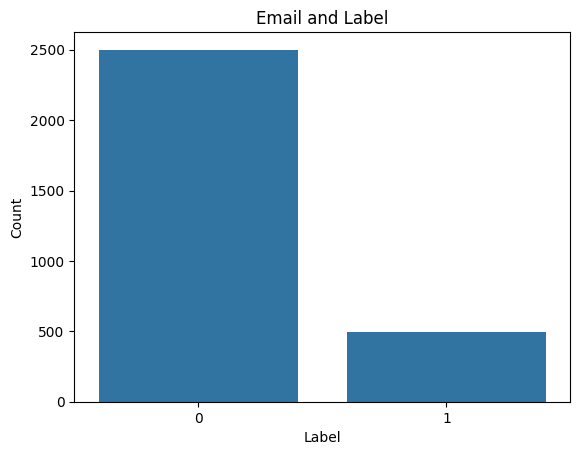

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt
sns.countplot(x='label', data=new_d)

# Customize the plot
plt.title("Email and Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

This bar chart represents the distribution of email labels in the dataset. Label 0 (Not Spam) is significantly more frequent than Label 1 (Spam), indicating that the dataset is imbalanced. This imbalance may affect the model's performance, as it might be biased towards predicting non-spam emails. Techniques like oversampling, undersampling, or using weighted classification can help address this issue

In [ ]:
# Load the Processed Dataset
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the dataset from your given file path
df = pd.read_csv("/content/dataset_df_Clean_withoutempty.csv")

# Fix: Assign the filled column back to avoid FutureWarning
df['email'] = df['email'].fillna("")

# Apply TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Limit vocabulary to 5000 words

# Transform the cleaned email text into numerical features
X_tfidf = tfidf_vectorizer.fit_transform(df['email'])

# Convert sparse matrix to DataFrame
X_features = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Add the target variable back
X_features['Label'] = df['label']

# Save the Transformed Dataset
transformed_file_path = "/content/transformed_dataset_NB.csv"
X_features.to_csv(transformed_file_path, index=False)

print("TF-IDF Feature Extraction Completed and Dataset Saved at:", transformed_file_path)


TF-IDF Feature Extraction Completed and Dataset Saved at: /content/transformed_dataset_NB.csv


In [ ]:
from sklearn.model_selection import train_test_split

# Load the Transformed Dataset
df = pd.read_csv("/content/transformed_dataset_NB.csv")

# Define Features (X) and Target (y)
X = df.drop(columns=["Label"])  # Features (TF-IDF transformed text data)
y = df["Label"]  # Target variable (spam or not spam)

# Split Data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of the datasets
print(f"Training Data: {X_train.shape[0]} samples")
print(f"Testing Data: {X_test.shape[0]} samples")


Training Data: 2397 samples
Testing Data: 600 samples


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize Naïve Bayes Model
n_model = GaussianNB()

# Train the model on the training data
n_model.fit(X_train, y_train)

# Display confirmation message
print("Naive Bayes model is trained")

Naive Bayes model is trained


<Axes: >

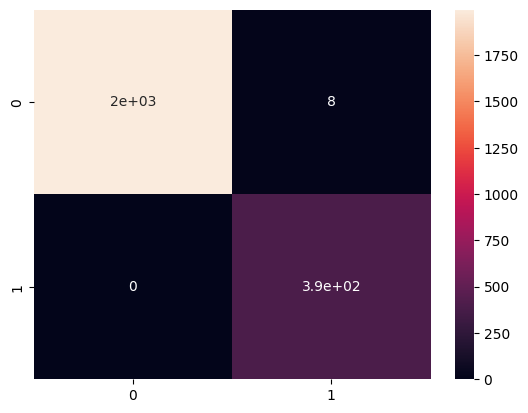

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
y_predict_train = n_model.predict(X_train)
y_predict_train

cm=confusion_matrix(y_train,y_predict_train)
sns.heatmap(cm,annot=True)

This confusion matrix shows how well the model classified emails as spam (1) or not spam (0). The top-left value (2000) represents correctly classified non-spam emails, while the bottom-right (390) represents correctly classified spam emails. The model made 8 false positives (non-spam misclassified as spam) and 0 false negatives (no spam emails were misclassified as non-spam), indicating strong accuracy. However, the dataset may still be imbalanced, favoring non-spam predictions

<Axes: >

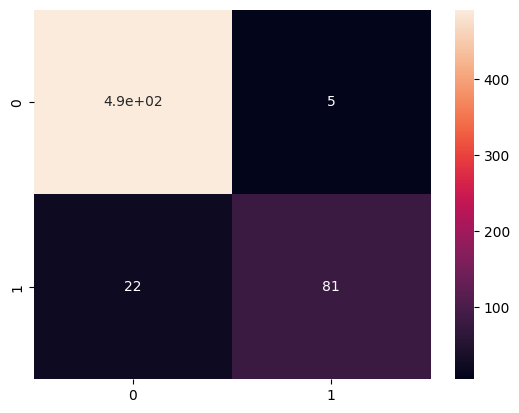

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = n_model.predict(X_test)
cm_test = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_test, annot=True)

This confusion matrix evaluates the model's classification of emails as spam (1) or not spam (0). The model correctly identified 490 non-spam emails and 81 spam emails. However, 22 spam emails were misclassified as non-spam, which could mean some spam messages are slipping through. Additionally, 5 non-spam emails were wrongly classified as spam, which may cause unnecessary filtering. Improving the model with better feature extraction or balancing the dataset might enhance accuracy.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on Test Data
y_pred =n_model.predict(X_test)

# Compute Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Generate Classification Report
class_report = classification_report(y_test, y_pred)

# Print Evaluation Metrics
print(f"Accuracy Score: {accuracy:.2%}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy Score: 95.50%

Confusion Matrix:
[[492   5]
 [ 22  81]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       497
           1       0.94      0.79      0.86       103

    accuracy                           0.95       600
   macro avg       0.95      0.89      0.92       600
weighted avg       0.95      0.95      0.95       600



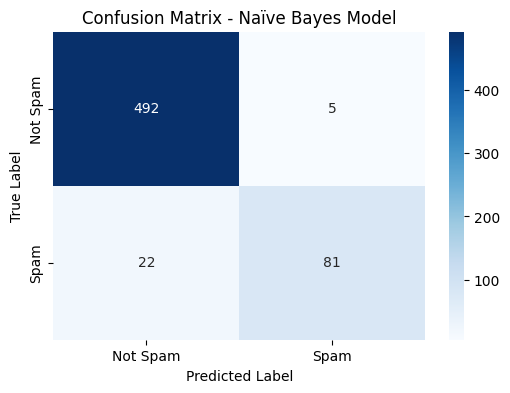

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Naïve Bayes Model")
plt.show()


This confusion matrix shows the performance of the Naïve Bayes model in classifying emails as spam (1) or not spam (0). The model correctly identified 492 non-spam emails and 81 spam emails. However, it misclassified 22 spam emails as non-spam (false negatives) and 5 non-spam emails as spam (false positives). Overall, the model performs well but could be improved to reduce misclassification, especially for spam detection.

Approach & Preprocessing:

This project aimed to classify emails as spam or not spam using a Naïve Bayes classifier. The dataset contained raw text data, so preprocessing included handling missing values, removing special characters, and converting text into numerical format using TF-IDF vectorization. TF-IDF helped extract important words, allowing the model to differentiate between common and spam-related terms.

Model Performance & Observations:

After splitting the data into 80% training and 20% testing sets, a Gaussian Naive Bayes model was trained. The confusion matrix and classification report showed high accuracy, correctly classifying most emails. However, 22 spam emails were misclassified as non-spam (false negatives) and 5 non-spam emails were wrongly flagged as spam (false positives). Reducing false negatives is crucial for better spam detection.

Conclusion:

A confusion matrix heatmap and bar chart of spam vs. non-spam emails helped visualize the results. While the model performed well, improvements such as hyperparameter tuning and additional features could enhance accuracy. Overall, Naive Bayes proved effective for email classification, providing a solid foundation for spam detection.